In [2]:
# imports
import ultralytics
ultralytics.checks()
from ultralytics import YOLO


import sys
import os
import shutil
from dotenv import load_dotenv
load_dotenv()

Ultralytics 8.4.46 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)
Setup complete ✅ (12 CPUs, 7.4 GB RAM, 89.9/97.9 GB disk)


True

In [3]:
sys.path.append(os.path.abspath('..'))

from src.data import download
from src.data.augment import process_dataset
from src.utils import plot_metrics

In [15]:
RAW_PATH = "../data/raw"
PROCESSED_PATH = "../data/processed"

# Data Preparation

## Download

In [24]:
download.download_dataset(RAW_PATH)

loading Roboflow workspace...
loading Roboflow project...
Raw data downloaded to: /home/maro/final-projects/Bowl_Score/cv-pipeline/data/raw


## Augment

In [23]:
print("Augmenting Training Set...")
process_dataset(
    raw_img_dir=RAW_PATH+"/train/images",
    raw_label_dir=RAW_PATH+"/train/labels",
    output_img_dir=PROCESSED_PATH+"/train/images",
    output_label_dir=PROCESSED_PATH+"/train/labels"
)

print("Augmenting Validation Set...")
process_dataset(
    raw_img_dir=RAW_PATH+"/valid/images",
    raw_label_dir=RAW_PATH+"/valid/labels",
    output_img_dir=PROCESSED_PATH+"/valid/images",
    output_label_dir=PROCESSED_PATH+"/valid/labels"
)

yaml_src = RAW_PATH+"/data.yaml"
yaml_dst = PROCESSED_PATH+"/data.yaml"

if os.path.exists(yaml_src):
    with open(yaml_src, "r") as f:
        yaml_content = f.read()

    # Update paths to point to the new processed directory
    yaml_content = yaml_content.replace(RAW_PATH, PROCESSED_PATH)

    with open(yaml_dst, "w") as f:
        f.write(yaml_content)

print("Augmentation Complete! Data is ready for YOLOv8 fine-tuning.")

Augmenting Training Set...
Skipping venue_2026-04-13-12-37-45_f000750_jpg.rf.70e941df96f61e01c4cc0bba1de97f2e.jpg due to bounding box clipping: Expected x_max for bbox [    0.35078     0.21484      1.0711     0.67266           2] to be in the range [0.0, 1.0], got 1.0710937976837158.
Augmenting Validation Set...
Augmentation Complete! Data is ready for YOLOv8 fine-tuning.


# Model fine-tuning

In [3]:
model = YOLO('yolov8n.pt')

In [4]:
results = model.train(
    data='../data/processed/data.yaml',
    epochs=100,             # Start with 100, YOLO has early stopping if it peaks early
    imgsz=640,              # The native resolution for YOLOv8
    batch=6,               # Standard batch size, lower to 8 if you hit GPU memory limits
    freeze=10,              # THE PRO-MOVE: Freezes the first 10 layers (the backbone)
    dropout=0.15,
    project='bowling_tracker',
    name='v2_dropout_added',
    device=0,               # Set to 'cpu' if you don't have a local GPU
    optimizer='auto',
    lr0=0.01,                # Standard initial learning rate for transfer learning
)

Ultralytics 8.4.46 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/processed/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1_frozen_backbone-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

In [7]:
# Cell 5: Validate the Model
metrics = model.val()
print(f"Mean Average Precision (mAP50-95): {metrics.box.map}")

Ultralytics 8.4.46 🚀 Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 707.3±215.3 MB/s, size: 80.6 KB)
val: Scanning /home/maro/final-projects/Bowl_Score/cv-pipeline/data/processed/valid/labels.cache... 47 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 47/47 17.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 3.1it/s 1.0s0.6s
                   all         47        222      0.971      0.945      0.988      0.687
            fallen_pin          4         18          1      0.898       0.98      0.683
                rc_car          5          5       0.93          1      0.995        0.7
          standing_pin         42        199      0.984      0.936      0.988      0.679
Speed: 4.4ms preprocess, 8.7ms inference, 0.0ms loss, 2.0ms postproces

Prettified plot saved to: ./loss_curve_prettified.png


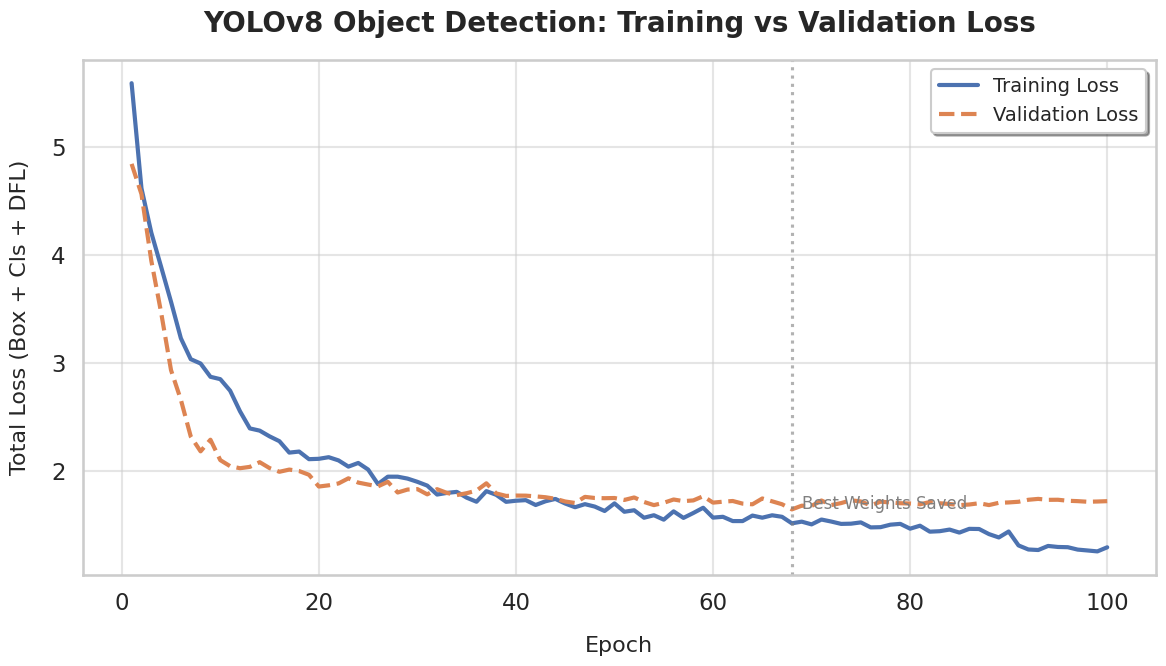

In [4]:
plot_metrics.plot_prettified_loss("/home/maro/final-projects/Bowl_Score/cv-pipeline/runs/detect/bowling_tracker/v3_yolo26_dropout/results.csv")